# SABR sequential implied-volatility surfaces

Generate a **time-ordered sequence** of SABR Black implied-volatility surfaces along a simulated SABR SDE path.

Flow:
- Draw LHS samples of `(alpha, rho, nu)` from `config/sabr_iv_surface.yaml`.
- For each draw, integrate the SABR SDE under the pricing measure for `n_steps` Euler steps of size `dt` (log-Euler on spot, exact GBM on `alpha`).
- At every step, regenerate the full IV surface on the shared `(moneyness, tau)` grid using the path's current `(spot_k, alpha_k)`.
- Every emitted surface is passed through the **arbitrage guard** defined in the config (`arbitrage_guard.policy`, default `repair`).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from implied_volatility_diffusion.config import merge_config, merge_config_files
from implied_volatility_diffusion.synthetic.sabr import (
    implied_vol_surfaces_sabr_sequential_lhs,
)
from implied_volatility_diffusion.arbitrage import check_iv_surfaces_arbitrage

sns.set_theme(context="notebook", style="ticks")

In [3]:
REPO_ROOT = Path("..").resolve()
CFG_DIR = REPO_ROOT / "config"

# Optional overrides - keep small for a fast demo run.
CFG_OVERRIDES: dict = {
    "lhs": {"n_samples": 4, "n_batches": 1, "seed": 11},
    "sequential_ivs": {"n_steps": 6, "dt": 1.0 / 252.0},
    # "arbitrage_guard": {"policy": "repair"},  # none | warn | repair | filter | raise
}

_base_cfg = merge_config_files(
    CFG_DIR / "sabr_iv_surface.yaml",
    CFG_DIR / "iv_surface_grid.yaml",
)
cfg = merge_config(_base_cfg, CFG_OVERRIDES or None)
{
    "spot": cfg["market"]["spot"],
    "r": cfg["market"].get("r", 0.0),
    "q": cfg["market"].get("dividend_yield", 0.0),
    "beta": cfg.get("sabr", {}).get("beta", 0.5),
    "n_samples": cfg["lhs"]["n_samples"],
    "n_steps": cfg["sequential_ivs"]["n_steps"],
    "dt": cfg["sequential_ivs"]["dt"],
    "arbitrage_guard": cfg.get("arbitrage_guard", {}),
}

{'spot': 100.0,
 'r': 0.03,
 'q': 0.0,
 'beta': 0.5,
 'n_samples': 4,
 'n_steps': 6,
 'dt': 0.003968253968253968,
 'arbitrage_guard': {'policy': 'repair',
  'tol': 1e-08,
  'repair_before_filter': True}}

In [4]:
params, m, tau, iv = implied_vol_surfaces_sabr_sequential_lhs(cfg)

print("params (alpha, rho, nu) :", params.shape)
print("moneyness              :", m.shape)
print("tau                    :", tau.shape)
print("iv (paths, steps, M, T):", iv.shape)
print(
    "iv stats               :",
    f"min={float(np.nanmin(iv)):.4f}",
    f"mean={float(np.nanmean(iv)):.4f}",
    f"max={float(np.nanmax(iv)):.4f}",
)

params (alpha, rho, nu) : (4, 3)
moneyness              : (21,)
tau                    : (40,)
iv (paths, steps, M, T): (4, 6, 21, 40)
iv stats               : min=0.0081 mean=0.0454 max=0.1244


In [5]:
# Per-step arbitrage diagnostics across the whole sequence.
spot = float(cfg["market"]["spot"])
rate = float(cfg["market"].get("r", 0.0))
dividend_yield = float(cfg["market"].get("dividend_yield", 0.0))

reports = check_iv_surfaces_arbitrage(
    iv, m, tau, spot=spot, rate=rate, dividend_yield=dividend_yield,
)
n_total = len(reports)
n_ok = sum(r.arbitrage_free for r in reports)
n_bfly = sum(int(not r.butterfly_ok) for r in reports)
n_cal = sum(int(not r.calendar_ok) for r in reports)
n_bnd = sum(int(not r.bounds_ok) for r in reports)
print(f"arbitrage-free surfaces : {n_ok}/{n_total}")
print(f"butterfly violations    : {n_bfly}")
print(f"calendar  violations    : {n_cal}")
print(f"bounds    violations    : {n_bnd}")

arbitrage-free surfaces : 24/24
butterfly violations    : 0
calendar  violations    : 0
bounds    violations    : 0


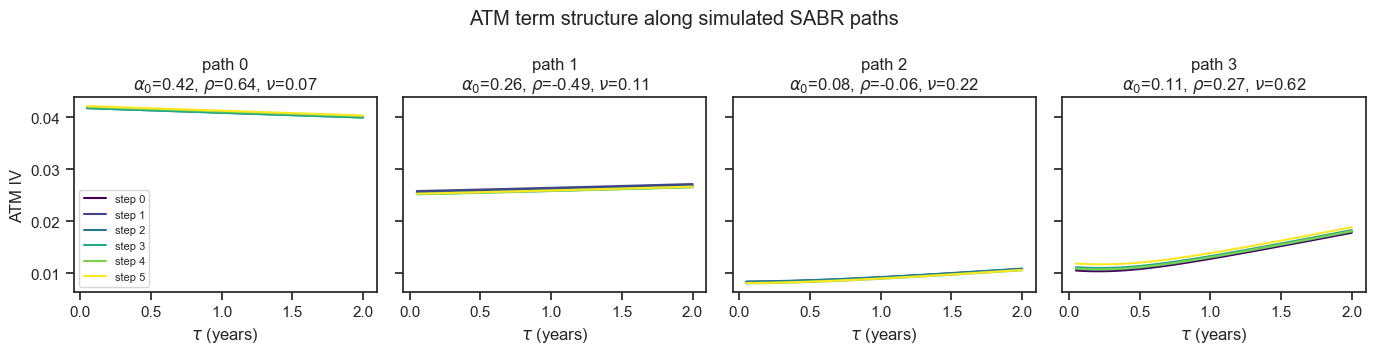

In [6]:
# ATM IV term-structure evolution per path and per step.
atm_idx = int(np.argmin(np.abs(m - 1.0)))
atm_iv = iv[:, :, atm_idx, :]  # (paths, steps, T)
n_paths, n_steps, _ = atm_iv.shape

fig, axes = plt.subplots(
    1, n_paths, figsize=(3.5 * n_paths, 3.6), sharey=True, squeeze=False,
)
cmap = plt.get_cmap("viridis")
for p in range(n_paths):
    ax = axes[0, p]
    for k in range(n_steps):
        ax.plot(
            tau, atm_iv[p, k], color=cmap(k / max(1, n_steps - 1)),
            label=f"step {k}" if p == 0 else None,
        )
    alpha0, rho_p, nu_p = params[p]
    ax.set_title(f"path {p}\n$\\alpha_0$={alpha0:.2f}, $\\rho$={rho_p:.2f}, $\\nu$={nu_p:.2f}")
    ax.set_xlabel(r"$\tau$ (years)")
    if p == 0:
        ax.set_ylabel("ATM IV")
axes[0, 0].legend(fontsize=8, loc="best")
fig.suptitle("ATM term structure along simulated SABR paths")
fig.tight_layout()
plt.show()

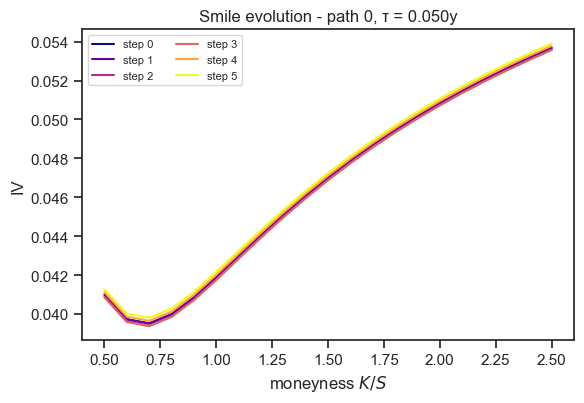

In [7]:
# Smile evolution for a single path at the shortest maturity on the grid.
path_idx = 0
tau_idx = 0
n_steps = iv.shape[1]
cmap = plt.get_cmap("plasma")

fig, ax = plt.subplots(figsize=(6.0, 4.2))
for k in range(n_steps):
    ax.plot(
        m, iv[path_idx, k, :, tau_idx],
        color=cmap(k / max(1, n_steps - 1)), label=f"step {k}",
    )
ax.set_xlabel("moneyness $K/S$")
ax.set_ylabel("IV")
ax.set_title(
    f"Smile evolution - path {path_idx}, \u03c4 = {float(tau[tau_idx]):.3f}y"
)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

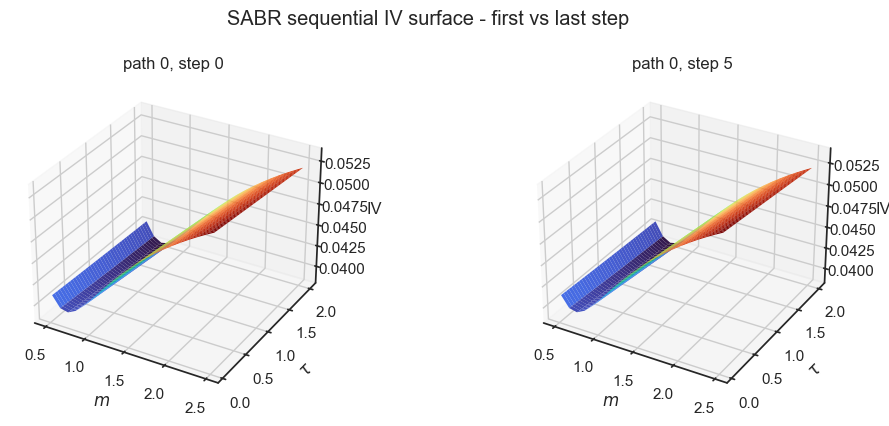

In [8]:
# Full surface at the first and last time step for one path.
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (side-effect: register 3D proj)

path_idx = 0
M, T = np.meshgrid(m, tau, indexing="ij")
steps_to_show = [0, iv.shape[1] - 1]

fig = plt.figure(figsize=(11, 4.2))
for i, step in enumerate(steps_to_show):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    ax.plot_surface(
        M, T, iv[path_idx, step], cmap="turbo", linewidth=0, antialiased=True,
    )
    ax.set_xlabel("$m$")
    ax.set_ylabel(r"$\tau$")
    ax.set_zlabel("IV")
    ax.set_title(f"path {path_idx}, step {step}")
fig.suptitle("SABR sequential IV surface - first vs last step")
fig.tight_layout()
plt.show()